In [119]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

In [331]:
df = pd.read_csv("Sample Data.csv")

In [332]:
df.head()

,Staff Key,faculty,school,broad_category,broad_contract_type,contract_type,contract_category,grade,gender,calc_fte,start_date,reporting_date
0,1140547C4,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Academic,Permanent,Perm on temp appt,Academic Non-Clinical,AC4,F,0.2,01/07/1998 00:00,31/05/2023 00:00
1,1140547C4,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Academic,Permanent,Perm on temp appt,Academic Non-Clinical,AC4,F,0.8,01/07/1998 00:00,31/05/2023 00:00
2,1140403 1,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Academic,Permanent,Perm on temp appt,Academic Non-Clinical,Professorial Range 1,M,0.4,01/08/2005 00:00,31/05/2023 00:00
3,1140403 1,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Academic,Permanent,Perm on temp appt,Academic Non-Clinical,Professorial Range 1,M,0.6,01/08/2005 00:00,31/05/2023 00:00
4,1140481 1,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Academic,Permanent,Perm on temp appt,Academic Non-Clinical,Professorial Range 1,M,0.2,01/07/2013 00:00,31/05/2023 00:00


In [4]:
# How many rows?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Staff Key            30000 non-null  object 
 1   faculty              30000 non-null  object 
 2   school               30000 non-null  object 
 3   broad_category       30000 non-null  object 
 4   broad_contract_type  30000 non-null  object 
 5   contract_type        30000 non-null  object 
 6   contract_category    30000 non-null  object 
 7   grade                30000 non-null  object 
 8   gender               30000 non-null  object 
 9   calc_fte             30000 non-null  float64
 10  start_date           30000 non-null  object 
 11  reporting_date       30000 non-null  object 
dtypes: float64(1), object(11)
memory usage: 2.7+ MB


30000 rows. All data are non-null

In [5]:
# Dictionary of unique column values
unique_dict = {col: df[col].unique() for col in df.columns}
unique_dict

{'Staff Key': array(['1140547C4', '1140403 1', '1140481 1', ..., '1110482 7',
        '1100568 7', '1130583 6'], shape=(1336,), dtype=object),
 'faculty': array(['Arts, Humanities and Social Sciences', 'Belfast Region City Deal',
        'Corporate', 'Engineering and Physical Sciences'], dtype=object),
 'school': array(['Faculty Office AHSS',
        'Inst for Global Peace, Security and Justice',
        'Inst of Professional Legal Studies', "Queen's Business School",
        'School of Arts, English and Languages',
        'School of History, Anthropology, Philosophy and Politics',
        'School of Law',
        'School of Social Sciences, Education and Social Work', 'AMIC',
        'BRCD Directorate Office', 'iREACH Health', 'Momentum 1.0',
        'University General', 'Faculty Office EPS'], dtype=object),
 'broad_category': array(['Academic', 'Professional and Support', 'Academic Education',
        'Research'], dtype=object),
 'broad_contract_type': array(['Permanent', 'Fixed'],

In [6]:
# Do contract categories always make sense for the broad category they are associated with?
df.groupby('contract_category')['broad_category'].unique()

contract_category
Acad-Rel Administrative              [Professional and Support]
Acad-Rel Computer                    [Professional and Support]
Acad-Rel ORS                               [Academic Education]
Academic Non-Clinical                                [Academic]
Academic Non-Clinical (Education)          [Academic Education]
Catering/Ancillary/Sport             [Professional and Support]
Cleaning                             [Professional and Support]
Clerical                             [Professional and Support]
Clerical Intern/Student              [Professional and Support]
Operational Intern/Student           [Professional and Support]
Research                                             [Research]
Research Academic                                    [Research]
Teaching Cons/Asst/Assoc                   [Academic Education]
Technical                            [Professional and Support]
Technical Intern/Student             [Professional and Support]
Name: broad_category, 

In [7]:
df.groupby('contract_type')['broad_contract_type'].unique()

contract_type
Fixed-term                         [Fixed]
Fixed-term - SPC                   [Fixed]
Fixed-term - acting up             [Fixed]
Perm - acting up               [Permanent]
Perm on temp appt              [Permanent]
Permanent                      [Permanent]
Permanent (Flex Retirement)    [Permanent]
Name: broad_contract_type, dtype: object

All contract types belong to only one broad contract type. All contract categories belong to only one broad category. This looks healthy

Are there any duplicate rows?

In [8]:
df.duplicated().sum()

np.int64(142)

In [333]:
# Drop 142 duplicate rows
df = df.drop_duplicates()

In [10]:
# Identify employees with more than one contract
df_multiple_contracts = df[df["Staff Key"].duplicated(keep=False)]
df_multiple_contracts

,Staff Key,faculty,school,broad_category,broad_contract_type,contract_type,contract_category,grade,gender,calc_fte,start_date,reporting_date
0,1140547C4,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Academic,Permanent,Perm on temp appt,Academic Non-Clinical,AC4,F,0.2,01/07/1998 00:00,31/05/2023 00:00
1,1140547C4,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Academic,Permanent,Perm on temp appt,Academic Non-Clinical,AC4,F,0.8,01/07/1998 00:00,31/05/2023 00:00
2,1140403 1,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Academic,Permanent,Perm on temp appt,Academic Non-Clinical,Professorial Range 1,M,0.4,01/08/2005 00:00,31/05/2023 00:00
3,1140403 1,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Academic,Permanent,Perm on temp appt,Academic Non-Clinical,Professorial Range 1,M,0.6,01/08/2005 00:00,31/05/2023 00:00
4,1140481 1,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Academic,Permanent,Perm on temp appt,Academic Non-Clinical,Professorial Range 1,M,0.2,01/07/2013 00:00,31/05/2023 00:00
...,...,...,...,...,...,...,...,...,...,...,...,...
29995,1110535 6,Engineering and Physical Sciences,Faculty Office EPS,Professional and Support,Permanent,Permanent,Acad-Rel Administrative,Grade 6,F,1.0,27/08/2018 00:00,30/09/2023 00:00
29996,1110539 6,Engineering and Physical Sciences,Faculty Office EPS,Professional and Support,Permanent,Permanent,Acad-Rel Administrative,Grade 6,M,1.0,21/11/2018 00:00,30/09/2023 00:00
29997,1110532 7,Engineering and Physical Sciences,Faculty Office EPS,Professional and Support,Permanent,Permanent,Acad-Rel Administrative,Grade 7,M,1.0,14/05/2018 00:00,30/09/2023 00:00
29998,1110534 7,Engineering and Physical Sciences,Faculty Office EPS,Professional and Support,Permanent,Permanent,Acad-Rel Administrative,Grade 7,F,1.0,01/08/2018 00:00,30/09/2023 00:00


In [11]:
df_multiple_contracts[df_multiple_contracts["Staff Key"] == "1110547 7"]

,Staff Key,faculty,school,broad_category,broad_contract_type,contract_type,contract_category,grade,gender,calc_fte,start_date,reporting_date
29813,1110547 7,Engineering and Physical Sciences,Faculty Office EPS,Professional and Support,Permanent,Permanent,Acad-Rel Administrative,Grade 7,F,1.0,05/08/2019 00:00,31/05/2023 00:00
29858,1110547 7,Engineering and Physical Sciences,Faculty Office EPS,Professional and Support,Permanent,Permanent,Acad-Rel Administrative,Grade 7,F,1.0,05/08/2019 00:00,30/06/2023 00:00
29904,1110547 7,Engineering and Physical Sciences,Faculty Office EPS,Professional and Support,Permanent,Permanent,Acad-Rel Administrative,Grade 7,F,1.0,05/08/2019 00:00,31/07/2023 00:00
29951,1110547 7,Engineering and Physical Sciences,Faculty Office EPS,Professional and Support,Permanent,Permanent,Acad-Rel Administrative,Grade 7,F,1.0,05/08/2019 00:00,31/08/2023 00:00
29999,1110547 7,Engineering and Physical Sciences,Faculty Office EPS,Professional and Support,Permanent,Permanent,Acad-Rel Administrative,Grade 7,F,1.0,05/08/2019 00:00,30/09/2023 00:00


In addition to 142 duplicate rows containing the same information in each column, there also seems to be instances where the same contract has been reported on different dates. As these are not distinct contracts the duplicates can be removed

In [334]:
cols = df.columns.drop("reporting_date")
df = df.drop_duplicates(subset=cols)

In [348]:
len(df)

1768

There appears to be 1768 unique contracts. Much lower than the 30000 originally recorded. 

In [14]:
# Redefine dataframe of employees with multiple contracts
df_multiple_contracts = df[df["Staff Key"].duplicated(keep=False)]
df_multiple_contracts

,Staff Key,faculty,school,broad_category,broad_contract_type,contract_type,contract_category,grade,gender,calc_fte,start_date,reporting_date
0,1140547C4,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Academic,Permanent,Perm on temp appt,Academic Non-Clinical,AC4,F,0.2,01/07/1998 00:00,31/05/2023 00:00
1,1140547C4,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Academic,Permanent,Perm on temp appt,Academic Non-Clinical,AC4,F,0.8,01/07/1998 00:00,31/05/2023 00:00
2,1140403 1,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Academic,Permanent,Perm on temp appt,Academic Non-Clinical,Professorial Range 1,M,0.4,01/08/2005 00:00,31/05/2023 00:00
3,1140403 1,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Academic,Permanent,Perm on temp appt,Academic Non-Clinical,Professorial Range 1,M,0.6,01/08/2005 00:00,31/05/2023 00:00
4,1140481 1,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Academic,Permanent,Perm on temp appt,Academic Non-Clinical,Professorial Range 1,M,0.2,01/07/2013 00:00,31/05/2023 00:00
...,...,...,...,...,...,...,...,...,...,...,...,...
29829,1000489 3,Engineering and Physical Sciences,Faculty Office EPS,Professional and Support,Permanent,Permanent,Clerical,Grade 3,F,0.8,05/06/2017 00:00,31/05/2023 00:00
29831,1110533 7,Engineering and Physical Sciences,Faculty Office EPS,Academic Education,Permanent,Permanent,Acad-Rel ORS,Grade 7,M,1.0,16/07/2018 00:00,31/05/2023 00:00
29832,1002562 8,Engineering and Physical Sciences,Faculty Office EPS,Professional and Support,Permanent,Permanent,Acad-Rel Computer,Grade 8,M,1.0,01/09/1988 00:00,31/05/2023 00:00
29834,1020725 9,Engineering and Physical Sciences,Faculty Office EPS,Academic Education,Permanent,Permanent,Acad-Rel ORS,Grade 9,M,1.0,02/04/2001 00:00,31/05/2023 00:00


There appear to be 705 employees who have held more than one type of contract. How many employees have had contracts with more than one grade?

In [284]:
df_changing_grades = df_multiple_contracts[df_multiple_contracts.groupby("Staff Key")["grade"].transform("nunique") > 1]

In [16]:
df_changing_grades

,Staff Key,faculty,school,broad_category,broad_contract_type,contract_type,contract_category,grade,gender,calc_fte,start_date,reporting_date
145,1150582 1,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Professional and Support,Fixed,Fixed-term - SPC,Clerical Intern/Student,Grade 1,F,1.0,01/08/2023 00:00,31/08/2023 00:00
146,1150582 1,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Professional and Support,Fixed,Fixed-term - SPC,Clerical Intern/Student,Grade 1,M,1.0,01/08/2023 00:00,31/08/2023 00:00
1535,1150583 1,"Arts, Humanities and Social Sciences","Inst for Global Peace, Security and Justice",Academic,Permanent,Permanent,Academic Non-Clinical,Professorial Range 1,F,1.0,01/01/2024 00:00,31/01/2024 00:00
7292,1160596 1,"Arts, Humanities and Social Sciences",Queen's Business School,Professional and Support,Fixed,Fixed-term - SPC,Clerical Intern/Student,Grade 1,M,1.0,23/07/2025 00:00,31/07/2025 00:00
21308,1160599 2,"Arts, Humanities and Social Sciences",School of Law,Academic,Permanent,Permanent,Academic Non-Clinical,Professorial Range 2,F,1.0,01/04/2026 00:00,30/04/2026 00:00
27039,1150583 1,Belfast Region City Deal,AMIC,Professional and Support,Fixed,Fixed-term - SPC,Operational Intern/Student,Grade 1,M,1.0,15/08/2023 00:00,31/08/2024 00:00
27827,1160599 2,Belfast Region City Deal,AMIC,Professional and Support,Fixed,Fixed-term,Technical,Grade 2,M,1.0,05/11/2025 00:00,30/11/2025 00:00
27828,1160599 2,Belfast Region City Deal,AMIC,Professional and Support,Fixed,Fixed-term,Technical,Grade 2,M,1.0,19/11/2025 00:00,30/11/2025 00:00
28632,1150582 1,Belfast Region City Deal,Momentum 1.0,Research,Fixed,Fixed-term,Research,ECIT Grade 1,M,1.0,24/07/2023 00:00,31/08/2024 00:00
29054,1160596 1,Belfast Region City Deal,Momentum 1.0,Research,Permanent,Permanent,Research,ECIT Grade 1,F,1.0,16/07/2025 00:00,31/07/2025 00:00


In [17]:
df_changing_grades["Staff Key"].nunique()

5

Only 5 out of 1336 staff appear to have changed grades. There is an issue with the Staff Key whereby the grade is used at the end of the Staff ID number. This means Staff Key is not a unique identifier for a staff member, but rather for a contract. 

Let's go back and identify unique staff members

In [335]:
df["Staff ID"] = df["Staff Key"].str[:7]

In [ ]:
# Convert date columns for temporal sorting 
df["start_date"] = pd.to_datetime(df["start_date"], format = "%d/%m/%Y %H:%M")
df["reporting_date"] = pd.to_datetime(df["reporting_date"], format = "%d/%m/%Y %H:%M")

In [19]:
df_multiple_contracts = df[df["Staff ID"].duplicated(keep=False)]
df_multiple_contracts

,Staff Key,faculty,school,broad_category,broad_contract_type,contract_type,contract_category,grade,gender,calc_fte,start_date,reporting_date,Staff ID
0,1140547C4,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Academic,Permanent,Perm on temp appt,Academic Non-Clinical,AC4,F,0.2,01/07/1998 00:00,31/05/2023 00:00,1140547
1,1140547C4,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Academic,Permanent,Perm on temp appt,Academic Non-Clinical,AC4,F,0.8,01/07/1998 00:00,31/05/2023 00:00,1140547
2,1140403 1,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Academic,Permanent,Perm on temp appt,Academic Non-Clinical,Professorial Range 1,M,0.4,01/08/2005 00:00,31/05/2023 00:00,1140403
3,1140403 1,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Academic,Permanent,Perm on temp appt,Academic Non-Clinical,Professorial Range 1,M,0.6,01/08/2005 00:00,31/05/2023 00:00,1140403
4,1140481 1,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Academic,Permanent,Perm on temp appt,Academic Non-Clinical,Professorial Range 1,M,0.2,01/07/2013 00:00,31/05/2023 00:00,1140481
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29834,1020725 9,Engineering and Physical Sciences,Faculty Office EPS,Academic Education,Permanent,Permanent,Acad-Rel ORS,Grade 9,M,1.0,02/04/2001 00:00,31/05/2023 00:00,1020725
29836,1120580 6,Engineering and Physical Sciences,Faculty Office EPS,Professional and Support,Permanent,Permanent,Acad-Rel Administrative,Grade 6,F,1.0,04/05/2023 00:00,31/05/2023 00:00,1120580
29839,1100535 5,Engineering and Physical Sciences,Faculty Office EPS,Professional and Support,Permanent,Perm on temp appt,Clerical,Grade 5,F,1.0,13/08/2018 00:00,30/06/2023 00:00,1100535
29859,1100568 7,Engineering and Physical Sciences,Faculty Office EPS,Professional and Support,Permanent,Permanent,Acad-Rel Administrative,Grade 7,F,1.0,05/10/2021 00:00,30/06/2023 00:00,1100568


In [20]:
df_changing_grades = df_multiple_contracts[df_multiple_contracts.groupby("Staff ID")["grade"].transform("nunique") > 1]

In [21]:
df_changing_grades

,Staff Key,faculty,school,broad_category,broad_contract_type,contract_type,contract_category,grade,gender,calc_fte,start_date,reporting_date,Staff ID
8,1100891 2,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Academic,Permanent,Perm on temp appt,Academic Non-Clinical,Professorial Range 2,M,0.3,01/07/2013 00:00,31/05/2023 00:00,1100891
9,1100891 2,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Academic,Permanent,Perm on temp appt,Academic Non-Clinical,Professorial Range 2,M,0.7,01/07/2013 00:00,31/05/2023 00:00,1100891
13,1090424 7,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Professional and Support,Permanent,Perm - acting up,Acad-Rel Administrative,Grade 7,F,1.0,20/08/2007 00:00,31/05/2023 00:00,1090424
19,1090129 B,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Professional and Support,Permanent,Permanent,Acad-Rel Administrative,Director B,F,1.0,26/08/1996 00:00,31/05/2023 00:00,1090129
26,1100564 6,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Professional and Support,Permanent,Permanent,Acad-Rel Administrative,Grade 6,M,1.0,16/03/2021 00:00,31/05/2023 00:00,1100564
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29833,1030961 8,Engineering and Physical Sciences,Faculty Office EPS,Academic Education,Permanent,Permanent,Acad-Rel ORS,Grade 8,M,1.0,01/02/2005 00:00,31/05/2023 00:00,1030961
29836,1120580 6,Engineering and Physical Sciences,Faculty Office EPS,Professional and Support,Permanent,Permanent,Acad-Rel Administrative,Grade 6,F,1.0,04/05/2023 00:00,31/05/2023 00:00,1120580
29839,1100535 5,Engineering and Physical Sciences,Faculty Office EPS,Professional and Support,Permanent,Perm on temp appt,Clerical,Grade 5,F,1.0,13/08/2018 00:00,30/06/2023 00:00,1100535
29859,1100568 7,Engineering and Physical Sciences,Faculty Office EPS,Professional and Support,Permanent,Permanent,Acad-Rel Administrative,Grade 7,F,1.0,05/10/2021 00:00,30/06/2023 00:00,1100568


In [336]:
(df.groupby("Staff ID")["grade"].nunique() > 1).value_counts()

grade
False    629
True     274
Name: count, dtype: int64

There are 274 employees who have changed grades versus 629 who have not. 

In [ ]:
# Do any employees move faculty when changing grades?
df_moving_faculties = df_changing_grades[df_changing_grades.groupby("Staff ID")["faculty"].transform("nunique") > 1]
df_moving_faculties

,Staff Key,faculty,school,broad_category,broad_contract_type,contract_type,contract_category,grade,gender,calc_fte,start_date,reporting_date,Staff ID
8,1100891 2,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Academic,Permanent,Perm on temp appt,Academic Non-Clinical,Professorial Range 2,M,0.3,01/07/2013 00:00,31/05/2023 00:00,1100891
9,1100891 2,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Academic,Permanent,Perm on temp appt,Academic Non-Clinical,Professorial Range 2,M,0.7,01/07/2013 00:00,31/05/2023 00:00,1100891
27,1120575 6,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Professional and Support,Permanent,Permanent,Acad-Rel Administrative,Grade 6,F,1.0,17/10/2022 00:00,31/05/2023 00:00,1120575
40,1120580 4,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Professional and Support,Permanent,Permanent,Clerical,Grade 4,M,1.0,31/05/2023 00:00,31/05/2023 00:00,1120580
41,1110539 6,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Professional and Support,Permanent,Permanent,Acad-Rel Administrative,Grade 6,M,1.0,26/11/2018 00:00,31/05/2023 00:00,1110539
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29831,1110533 7,Engineering and Physical Sciences,Faculty Office EPS,Academic Education,Permanent,Permanent,Acad-Rel ORS,Grade 7,M,1.0,16/07/2018 00:00,31/05/2023 00:00,1110533
29833,1030961 8,Engineering and Physical Sciences,Faculty Office EPS,Academic Education,Permanent,Permanent,Acad-Rel ORS,Grade 8,M,1.0,01/02/2005 00:00,31/05/2023 00:00,1030961
29836,1120580 6,Engineering and Physical Sciences,Faculty Office EPS,Professional and Support,Permanent,Permanent,Acad-Rel Administrative,Grade 6,F,1.0,04/05/2023 00:00,31/05/2023 00:00,1120580
29839,1100535 5,Engineering and Physical Sciences,Faculty Office EPS,Professional and Support,Permanent,Perm on temp appt,Clerical,Grade 5,F,1.0,13/08/2018 00:00,30/06/2023 00:00,1100535


In [24]:
df_moving_faculties["Staff ID"].nunique()

63

274 employees changed grades, of which 63 changed faculty.

Some employees appear to have the 2 instances of the start date and FTE is divided between 2 contracts

In [286]:
pd.set_option('display.max_rows', 20)

In [26]:
df_divided_fte = df_changing_grades[df_changing_grades.duplicated(subset = ["Staff Key", "start_date"], keep=False)]
df_divided_fte =df_divided_fte.sort_values(["Staff ID", "start_date"])
df_divided_fte

,Staff Key,faculty,school,broad_category,broad_contract_type,contract_type,contract_category,grade,gender,calc_fte,start_date,reporting_date,Staff ID
13611,1000473C3,"Arts, Humanities and Social Sciences","School of History, Anthropology, Philosophy an...",Academic,Permanent,Permanent,Academic Non-Clinical,AC3,M,1.000,01/09/2012 00:00,31/05/2023 00:00,1000473
13612,1000473C3,"Arts, Humanities and Social Sciences","School of History, Anthropology, Philosophy an...",Academic,Permanent,Permanent,Academic Non-Clinical,AC3,F,1.000,01/09/2012 00:00,31/05/2023 00:00,1000473
2230,1000534 4,"Arts, Humanities and Social Sciences",Queen's Business School,Professional and Support,Permanent,Permanent,Clerical,Grade 4,F,1.000,20/08/2018 00:00,31/05/2023 00:00,1000534
3328,1000534 4,"Arts, Humanities and Social Sciences",Queen's Business School,Professional and Support,Permanent,Permanent,Clerical,Grade 4,F,0.500,20/08/2018 00:00,30/11/2023 00:00,1000534
21439,1010572 5,"Arts, Humanities and Social Sciences","School of Social Sciences, Education and Socia...",Professional and Support,Fixed,Fixed-term,Clerical,Grade 5,F,0.600,23/05/2022 00:00,31/05/2023 00:00,1010572
...,...,...,...,...,...,...,...,...,...,...,...,...,...
26820,1160599C2,"Arts, Humanities and Social Sciences","School of Social Sciences, Education and Socia...",Research,Fixed,Fixed-term,Research,AC2,F,0.268,15/10/2025 00:00,31/03/2026 00:00,1160599
26821,1160599C2,"Arts, Humanities and Social Sciences","School of Social Sciences, Education and Socia...",Research,Fixed,Fixed-term,Research,AC2,F,0.300,15/10/2025 00:00,31/03/2026 00:00,1160599
26822,1160599C2,"Arts, Humanities and Social Sciences","School of Social Sciences, Education and Socia...",Research,Fixed,Fixed-term,Research,AC2,F,0.328,15/10/2025 00:00,31/03/2026 00:00,1160599
26798,1160601 5,"Arts, Humanities and Social Sciences","School of Social Sciences, Education and Socia...",Professional and Support,Fixed,Fixed-term,Clerical,Grade 5,F,1.000,23/03/2026 00:00,31/03/2026 00:00,1160601


In [27]:
df_divided_fte["Staff Key"].nunique()

115

115 employees have multiple contracts on the same start date

In [28]:
df_different_start_dates = df_multiple_contracts[df_multiple_contracts.groupby("Staff ID")["start_date"].transform("nunique") > 1]
df_different_start_dates

,Staff Key,faculty,school,broad_category,broad_contract_type,contract_type,contract_category,grade,gender,calc_fte,start_date,reporting_date,Staff ID
8,1100891 2,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Academic,Permanent,Perm on temp appt,Academic Non-Clinical,Professorial Range 2,M,0.3,01/07/2013 00:00,31/05/2023 00:00,1100891
9,1100891 2,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Academic,Permanent,Perm on temp appt,Academic Non-Clinical,Professorial Range 2,M,0.7,01/07/2013 00:00,31/05/2023 00:00,1100891
27,1120575 6,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Professional and Support,Permanent,Permanent,Acad-Rel Administrative,Grade 6,F,1.0,17/10/2022 00:00,31/05/2023 00:00,1120575
28,1120547 7,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Professional and Support,Permanent,Permanent,Acad-Rel Administrative,Grade 7,F,0.8,01/02/1996 00:00,31/05/2023 00:00,1120547
31,1100519 7,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Professional and Support,Permanent,Permanent,Acad-Rel Administrative,Grade 7,F,1.0,24/04/2017 00:00,31/05/2023 00:00,1100519
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29824,1120556 8,Engineering and Physical Sciences,Faculty Office EPS,Academic Education,Fixed,Fixed-term,Acad-Rel ORS,Grade 8,M,1.0,01/04/2020 00:00,31/05/2023 00:00,1120556
29831,1110533 7,Engineering and Physical Sciences,Faculty Office EPS,Academic Education,Permanent,Permanent,Acad-Rel ORS,Grade 7,M,1.0,16/07/2018 00:00,31/05/2023 00:00,1110533
29836,1120580 6,Engineering and Physical Sciences,Faculty Office EPS,Professional and Support,Permanent,Permanent,Acad-Rel Administrative,Grade 6,F,1.0,04/05/2023 00:00,31/05/2023 00:00,1120580
29839,1100535 5,Engineering and Physical Sciences,Faculty Office EPS,Professional and Support,Permanent,Perm on temp appt,Clerical,Grade 5,F,1.0,13/08/2018 00:00,30/06/2023 00:00,1100535


In [29]:
df_divided_fte[df_divided_fte["Staff ID"] == "1030084"]

,Staff Key,faculty,school,broad_category,broad_contract_type,contract_type,contract_category,grade,gender,calc_fte,start_date,reporting_date,Staff ID
21379,1030084 1,"Arts, Humanities and Social Sciences","School of Social Sciences, Education and Socia...",Academic,Permanent,Permanent,Academic Non-Clinical,Professorial Range 1,F,0.2,01/11/1995 00:00,31/05/2023 00:00,1030084
21380,1030084 1,"Arts, Humanities and Social Sciences","School of Social Sciences, Education and Socia...",Academic,Permanent,Permanent,Academic Non-Clinical,Professorial Range 1,F,0.8,01/11/1995 00:00,31/05/2023 00:00,1030084
24258,1030084 1,"Arts, Humanities and Social Sciences","School of Social Sciences, Education and Socia...",Academic,Permanent,Permanent,Academic Non-Clinical,Professorial Range 1,F,1.0,01/11/1995 00:00,30/11/2024 00:00,1030084
25727,1030084 2,"Arts, Humanities and Social Sciences","School of Social Sciences, Education and Socia...",Academic,Permanent,Permanent,Academic Non-Clinical,Professorial Range 2,F,0.2,01/11/1995 00:00,31/08/2025 00:00,1030084
25728,1030084 2,"Arts, Humanities and Social Sciences","School of Social Sciences, Education and Socia...",Academic,Permanent,Permanent,Academic Non-Clinical,Professorial Range 2,F,0.8,01/11/1995 00:00,31/08/2025 00:00,1030084


This employee apparently started 5 contracts on the same date. Start date must relate to the date the staff member first joined the university. Let's assume that all the other metrics are correct and that each row with non-duplicate data represents a unique contract. This issue could be solved if each contract has a unique contract ID. As it stands, the Staff Key will be the same across contracts on the same grade, regardless of the contract type and FTE.

In [30]:
ct_grades = pd.crosstab(df["faculty"], df["grade"], normalize="index")

In [31]:

ct_grades_long = (
    ct_grades.reset_index()
      .melt(id_vars="faculty", var_name="grade", value_name="proportion")
      .sort_values(["faculty", "proportion"], ascending=[True, False])
      .groupby("faculty")
      .head(5)
)


In [32]:
ct_grades_long

,faculty,grade,proportion
4,"Arts, Humanities and Social Sciences",AC2,0.186395
8,"Arts, Humanities and Social Sciences",AC3,0.151701
12,"Arts, Humanities and Social Sciences",AC4,0.146259
72,"Arts, Humanities and Social Sciences",Grade 4,0.076190
100,"Arts, Humanities and Social Sciences",Professorial Range 1,0.072789
85,Belfast Region City Deal,Grade 7,0.219298
89,Belfast Region City Deal,Grade 8,0.140351
77,Belfast Region City Deal,Grade 5,0.087719
81,Belfast Region City Deal,Grade 6,0.078947
33,Belfast Region City Deal,ECIT Grade 1,0.070175


In [33]:
ct_broad_category = pd.crosstab(df["faculty"], df["broad_category"], normalize="index")

In [34]:
ct_broad_category_long = (
    ct_broad_category.reset_index()
      .melt(id_vars="faculty", var_name="broad_category", value_name="proportion")
      .sort_values(["faculty", "proportion"], ascending=[True, False])
      .groupby("faculty")
      .head(5)
)

In [35]:
ct_broad_category_long

,faculty,broad_category,proportion
0,"Arts, Humanities and Social Sciences",Academic,0.474150
8,"Arts, Humanities and Social Sciences",Professional and Support,0.277551
12,"Arts, Humanities and Social Sciences",Research,0.148299
4,"Arts, Humanities and Social Sciences",Academic Education,0.100000
9,Belfast Region City Deal,Professional and Support,0.618421
13,Belfast Region City Deal,Research,0.201754
5,Belfast Region City Deal,Academic Education,0.175439
1,Belfast Region City Deal,Academic,0.004386
10,Corporate,Professional and Support,1.000000
2,Corporate,Academic,0.000000


Arts, Humanities and Social Sciences has the highest proportion of Academic staff (47%). Engineering and Physical Sciences and Belfast Region City Deal both have a high proportion of Professional and Support staff (63% and 62% respectively). Corporate consists entirely of Professional and Support staff. 

In [ ]:
# How many staff have changed contract in each category?

(df.groupby("Staff ID")[["grade", "faculty", "contract_type", "broad_category", "broad_contract_type", "calc_fte", "school"]]
   .nunique()
   .gt(1)
   .sum())


grade                  274
faculty                 72
contract_type          121
broad_category         129
broad_contract_type     81
calc_fte               159
school                 167
dtype: int64

In [270]:

df_changing_grades = df_changing_grades.sort_values(by = ["Staff ID", "reporting_date"])
paths = (
    df_changing_grades.groupby("Staff ID")["grade"]
      .unique()
      .apply(tuple)
      .value_counts()
)


In [272]:
paths

grade
(AC4, AC5)                                                                             31
(AC3, AC4)                                                                             28
(AC2, AC3)                                                                             17
(AC5, Professorial Range 1)                                                            13
(AC4, Professorial Range 1)                                                            12
(AC4, Grade 7)                                                                          5
(AC2, Grade 5)                                                                          5
(AC2, Grade 7, AC3)                                                                     4
(Professorial Range 1, Professorial Range 2)                                            4
(AC3, Grade 7, AC4)                                                                     4
(AC3, AC4, AC5)                                                                         4
(AC3

In [271]:
len(paths)

128

There are 122 different grade progression routes, with the most common being:

AC4 -> AC5 <br>
AC3 -> AC4 <br>
AC2 -> AC3 <br>
AC5 -> Professorial Range 1 <br>
AC4 -> Professorial Range 1

In [220]:
df = df.sort_values(by = ["Staff ID", "grade"])
grade_paths = (
    df.groupby("Staff ID")["grade"]
      .unique()
      .apply(tuple)
      .value_counts()
)

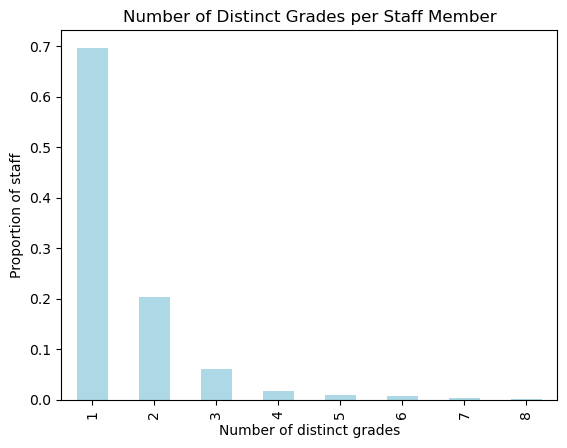

In [197]:
mobility = grade_paths.copy()
mobility.index = mobility.index.map(len)

mobility = mobility.groupby(mobility.index).sum()
mobility = mobility / mobility.sum()

mobility.plot(kind='bar', color = "lightblue")

plt.xlabel('Number of distinct grades')
plt.ylabel('Proportion of staff')
plt.title('Number of Distinct Grades per Staff Member')
plt.show()

In [198]:
mobility

grade
1    0.696567
2    0.203765
3    0.060908
4    0.016611
5    0.008859
6    0.007752
7    0.003322
8    0.002215
Name: count, dtype: float64

In [199]:
# By faculty

dfs_by_faculty = {
    faculty: g.sort_values(by=['Staff ID', 'grade'])
    for faculty, g in df.groupby('faculty')
}


In [206]:
grade_paths_ahss = (
    dfs_by_faculty["Arts, Humanities and Social Sciences"].groupby("Staff ID")["grade"]
      .unique()
      .apply(tuple)
      .value_counts()
)

grade_paths_eng = (
    dfs_by_faculty["Engineering and Physical Sciences"].groupby("Staff ID")["grade"]
      .unique()
      .apply(tuple)
      .value_counts()
)

grade_paths_belfast = (
    dfs_by_faculty["Belfast Region City Deal"].groupby("Staff ID")["grade"]
      .unique()
      .apply(tuple)
      .value_counts()
)

grade_paths_corporate = (
    dfs_by_faculty["Corporate"].groupby("Staff ID")["grade"]
      .unique()
      .apply(tuple)
      .value_counts()
)

In [207]:
mobility_ahss = grade_paths_ahss.copy()
mobility_ahss.index = mobility_ahss.index.map(len)

mobility_ahss = mobility_ahss.groupby(mobility_ahss.index).sum()
mobility_ahss = mobility_ahss / mobility_ahss.sum()

mobility_eng = grade_paths_eng.copy()
mobility_eng.index = mobility_eng.index.map(len)

mobility_eng = mobility_eng.groupby(mobility_eng.index).sum()
mobility_eng = mobility_eng / mobility_eng.sum()

mobility_belfast = grade_paths_belfast.copy()
mobility_belfast.index = mobility_belfast.index.map(len)

mobility_belfast = mobility_belfast.groupby(mobility_belfast.index).sum()
mobility_belfast = mobility_belfast / mobility_belfast.sum()

mobility_corporate = grade_paths_corporate.copy()
mobility_corporate.index = mobility_corporate.index.map(len)

mobility_corporate = mobility_corporate.groupby(mobility_corporate.index).sum()
mobility_corporate = mobility_corporate / mobility_corporate.sum()

In [208]:
mobility_ahss

grade
1    0.691026
2    0.217949
3    0.060256
4    0.019231
5    0.006410
6    0.005128
Name: count, dtype: float64

In [209]:
mobility_eng

grade
1    0.957447
2    0.042553
Name: count, dtype: float64

In [210]:
mobility_belfast

grade
1    0.839416
2    0.116788
3    0.014599
4    0.014599
5    0.014599
Name: count, dtype: float64

In [211]:
mobility_corporate

grade
1    1.0
Name: count, dtype: float64

In [329]:
df = df.sort_values(by = ["Staff ID", "reporting_date"])

In [330]:
df.head()

,Staff Key,faculty,school,broad_category,broad_contract_type,contract_type,contract_category,grade,gender,calc_fte,start_date,reporting_date,Staff ID,prev_grade,prev_faculty,grade_changed,faculty_changed
1742,1000032C4,"Arts, Humanities and Social Sciences",Inst of Professional Legal Studies,Academic Education,Permanent,Permanent,Academic Non-Clinical (Education),AC4,F,0.5,01/09/1995 00:00,2023-05-31,1000032,NaN,NaN,False,False
13672,1000405 2,"Arts, Humanities and Social Sciences","School of History, Anthropology, Philosophy and Politics",Academic,Permanent,Permanent,Academic Non-Clinical,Professorial Range 2,M,1.0,01/10/2005 00:00,2023-05-31,1000405,NaN,NaN,False,False
7344,1000418C4,"Arts, Humanities and Social Sciences","School of Arts, English and Languages",Academic,Permanent,Permanent,Academic Non-Clinical,AC4,F,1.0,01/12/2006 00:00,2023-05-31,1000418,NaN,NaN,False,False
13610,1000423C3,"Arts, Humanities and Social Sciences","School of History, Anthropology, Philosophy and Politics",Academic,Permanent,Permanent,Academic Non-Clinical,AC3,M,1.0,01/09/2007 00:00,2023-05-31,1000423,NaN,NaN,False,False
18195,1000425 2,"Arts, Humanities and Social Sciences",School of Law,Academic,Permanent,Permanent,Academic Non-Clinical,Professorial Range 2,F,1.0,01/09/2018 00:00,2023-05-31,1000425,NaN,NaN,False,False


In [290]:
# Grade Changes where faculty also changes


df['prev_grade'] = df.groupby('Staff ID')['grade'].shift()
df['prev_faculty'] = df.groupby('Staff ID')['faculty'].shift()




df['grade_changed'] = (
    df['grade'] != df['prev_grade']
) & df['prev_grade'].notna()

df['faculty_changed'] = (
    df['faculty'] != df['prev_faculty']
) & df['prev_faculty'].notna()


movers = df[df['grade_changed'] & df['faculty_changed']]

In [345]:
movers.head(10).sort_values(by = "Staff ID")

,Staff Key,faculty,school,broad_category,broad_contract_type,contract_type,contract_category,grade,gender,calc_fte,start_date,reporting_date,Staff ID,prev_grade,prev_faculty,grade_changed,faculty_changed
29833,1030961 8,Engineering and Physical Sciences,Faculty Office EPS,Academic Education,Permanent,Permanent,Acad-Rel ORS,Grade 8,M,1.0,01/02/2005 00:00,2023-05-31,1030961,Professorial Range 1,"Arts, Humanities and Social Sciences",True,True
29806,1100420 5,Engineering and Physical Sciences,Faculty Office EPS,Professional and Support,Permanent,Permanent,Clerical,Grade 5,F,1.0,19/02/2007 00:00,2023-05-31,1100420,Grade 4,"Arts, Humanities and Social Sciences",True,True
28988,1100523 2,Belfast Region City Deal,Momentum 1.0,Professional and Support,Permanent,Permanent,Acad-Rel Administrative,ECIT Grade 2,M,1.0,04/09/2017 00:00,2025-06-30,1100523,AC4,"Arts, Humanities and Social Sciences",True,True
816,1100535 7,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Professional and Support,Permanent,Perm on temp appt,Acad-Rel Administrative,Grade 7,F,1.0,27/08/2018 00:00,2024-10-31,1100535,Grade 5,Engineering and Physical Sciences,True,True
29803,1100553 3,Engineering and Physical Sciences,Faculty Office EPS,Professional and Support,Permanent,Permanent,Clerical,Grade 3,F,0.6,08/01/2020 00:00,2023-05-31,1100553,Grade 6,"Arts, Humanities and Social Sciences",True,True
3159,1100553 7,"Arts, Humanities and Social Sciences",Queen's Business School,Professional and Support,Permanent,Permanent,Acad-Rel Administrative,Grade 7,F,1.0,06/01/2020 00:00,2023-10-31,1100553,Grade 3,Engineering and Physical Sciences,True,True
28444,1100584 5,Belfast Region City Deal,iREACH Health,Professional and Support,Permanent,Permanent,Clerical,Grade 5,F,1.0,19/10/2023 00:00,2025-09-30,1100584,AC3,"Arts, Humanities and Social Sciences",True,True
29814,1100891 8,Engineering and Physical Sciences,Faculty Office EPS,Professional and Support,Permanent,Permanent,Acad-Rel Administrative,Grade 8,M,1.0,01/05/2003 00:00,2023-05-31,1100891,Professorial Range 2,"Arts, Humanities and Social Sciences",True,True
28642,1110530 1,Belfast Region City Deal,Momentum 1.0,Professional and Support,Permanent,Permanent,Acad-Rel Administrative,ECIT Grade 1,F,0.1,20/03/2018 00:00,2024-08-31,1110530,AC4,"Arts, Humanities and Social Sciences",True,True
29831,1110533 7,Engineering and Physical Sciences,Faculty Office EPS,Academic Education,Permanent,Permanent,Acad-Rel ORS,Grade 7,M,1.0,16/07/2018 00:00,2023-05-31,1110533,AC3,"Arts, Humanities and Social Sciences",True,True


In [292]:
len(movers)

110

In [293]:
mask = movers['Staff ID'].duplicated(keep=False)

movers_one_time = movers[~mask]
movers_multiple = movers[mask]


In [266]:
movers_one_time.head(10).sort_values(by = "Staff ID")

,Staff Key,faculty,school,broad_category,broad_contract_type,contract_type,contract_category,grade,gender,calc_fte,start_date,reporting_date,Staff ID,prev_grade,prev_faculty,grade_changed,faculty_changed
21386,1030961 1,"Arts, Humanities and Social Sciences","School of Social Sciences, Education and Socia...",Academic,Permanent,Permanent,Academic Non-Clinical,Professorial Range 1,M,1.0,01/02/2005 00:00,31/05/2023 00:00,1030961,Grade 8,Engineering and Physical Sciences,True,True
28988,1100523 2,Belfast Region City Deal,Momentum 1.0,Professional and Support,Permanent,Permanent,Acad-Rel Administrative,ECIT Grade 2,M,1.0,04/09/2017 00:00,30/06/2025 00:00,1100523,AC4,"Arts, Humanities and Social Sciences",True,True
816,1100535 7,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Professional and Support,Permanent,Perm on temp appt,Acad-Rel Administrative,Grade 7,F,1.0,27/08/2018 00:00,31/10/2024 00:00,1100535,Grade 5,Engineering and Physical Sciences,True,True
2241,1100553 6,"Arts, Humanities and Social Sciences",Queen's Business School,Professional and Support,Permanent,Permanent,Clerical,Grade 6,F,1.0,06/01/2020 00:00,31/05/2023 00:00,1100553,Grade 3,Engineering and Physical Sciences,True,True
28444,1100584 5,Belfast Region City Deal,iREACH Health,Professional and Support,Permanent,Permanent,Clerical,Grade 5,F,1.0,19/10/2023 00:00,30/09/2025 00:00,1100584,AC3,"Arts, Humanities and Social Sciences",True,True
8,1100891 2,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Academic,Permanent,Perm on temp appt,Academic Non-Clinical,Professorial Range 2,M,0.3,01/07/2013 00:00,31/05/2023 00:00,1100891,Grade 8,Engineering and Physical Sciences,True,True
27046,1110533 7,Belfast Region City Deal,AMIC,Academic Education,Permanent,Permanent,Acad-Rel ORS,Grade 7,M,1.0,16/07/2018 00:00,31/08/2024 00:00,1110533,AC3,"Arts, Humanities and Social Sciences",True,True
29812,1110534 7,Engineering and Physical Sciences,Faculty Office EPS,Professional and Support,Permanent,Permanent,Acad-Rel Administrative,Grade 7,F,1.0,01/08/2018 00:00,31/05/2023 00:00,1110534,AC4,"Arts, Humanities and Social Sciences",True,True
7406,1120541 2,"Arts, Humanities and Social Sciences","School of Arts, English and Languages",Academic,Permanent,Permanent,Academic Non-Clinical,Professorial Range 2,M,0.2,01/02/2019 00:00,31/05/2023 00:00,1120541,AC1,Belfast Region City Deal,True,True
18121,1120554C2,"Arts, Humanities and Social Sciences",School of Law,Research,Fixed,Fixed-term,Research,AC2,F,1.0,01/02/2020 00:00,31/05/2023 00:00,1120554,AC1,Belfast Region City Deal,True,True


In [294]:
movers["Staff ID"].nunique()

62

In [295]:
movers_multiple["Staff ID"].nunique()

24

In [296]:
len(movers_one_time)

38

In [ ]:
pairs = (
    movers.loc[~mask, ['faculty', 'prev_faculty']]
          .apply(lambda x: tuple(sorted(x)), axis=1)
)

pair_counts = pairs.value_counts().reset_index()
pair_counts.columns = ['faculty_pair', 'count']


In [309]:
pair_counts

,faculty_pair,count
0,"(Arts, Humanities and Social Sciences, Belfast...",29
1,"(Arts, Humanities and Social Sciences, Enginee...",6
2,"(Belfast Region City Deal, Engineering and Phy...",1
3,"(Belfast Region City Deal, Corporate)",1
4,"(Arts, Humanities and Social Sciences, Corporate)",1


In [311]:

multiple_movers = (
    movers
    .groupby('Staff ID')
    .apply(
        lambda x: tuple(
            [x['prev_faculty'].iloc[0]] + x['faculty'].tolist()
        )
    )
)


C:\Users\Niall.Russell\AppData\Local\Temp\ipykernel_50068\2976565087.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [313]:
multiple_movers = multiple_movers[multiple_movers.map(len) > 2]

In [320]:
eight_time_mover = multiple_movers[multiple_movers.map(len) > 7]

In [321]:
eight_time_mover

Staff ID
1150589    (Arts, Humanities and Social Sciences, Belfast Region City Deal, Arts, Humanities and Social Sciences, Belfast Region City Deal, Arts, Humanities and Social Sciences, Belfast Region City Deal, Arts, Humanities and Social Sciences, Belfast Region City Deal)
1160598    (Arts, Humanities and Social Sciences, Belfast Region City Deal, Arts, Humanities and Social Sciences, Belfast Region City Deal, Arts, Humanities and Social Sciences, Belfast Region City Deal, Arts, Humanities and Social Sciences, Belfast Region City Deal)
dtype: object

In [340]:
df[df["Staff ID"] == "1150589"].sort_values(by = "reporting_date")


,Staff Key,faculty,school,broad_category,broad_contract_type,contract_type,contract_category,grade,gender,calc_fte,start_date,reporting_date,Staff ID
661,1150589 1,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Professional and Support,Fixed,Fixed-term - SPC,Clerical Intern/Student,Grade 1,F,1.0,2024-06-17,2024-06-30,1150589
4692,1150589 4,"Arts, Humanities and Social Sciences",Queen's Business School,Professional and Support,Permanent,Permanent,Clerical,Grade 4,M,1.0,2024-06-17,2024-06-30,1150589
27049,1150589 6,Belfast Region City Deal,AMIC,Academic Education,Fixed,Fixed-term,Acad-Rel ORS,Grade 6,M,1.0,2024-07-08,2024-08-31,1150589
27036,1150589 7,Belfast Region City Deal,AMIC,Academic Education,Fixed,Fixed-term,Acad-Rel ORS,Grade 7,M,1.0,2024-08-14,2024-08-31,1150589
27035,1150589 7,Belfast Region City Deal,AMIC,Academic Education,Fixed,Fixed-term,Acad-Rel ORS,Grade 7,M,1.0,2024-07-01,2024-08-31,1150589
27034,1150589 7,Belfast Region City Deal,AMIC,Academic Education,Fixed,Fixed-term,Acad-Rel ORS,Grade 7,M,1.0,2024-05-20,2024-08-31,1150589
27028,1150589 6,Belfast Region City Deal,AMIC,Academic Education,Fixed,Fixed-term,Acad-Rel ORS,Grade 6,M,1.0,2024-05-27,2024-08-31,1150589
28362,1150589 7,Belfast Region City Deal,iREACH Health,Professional and Support,Fixed,Fixed-term,Acad-Rel Administrative,Grade 7,M,1.0,2024-08-14,2024-08-31,1150589
27022,1150589 8,Belfast Region City Deal,AMIC,Professional and Support,Fixed,Fixed-term,Acad-Rel Administrative,Grade 8,M,1.0,2024-06-01,2024-08-31,1150589
19472,1150589C2,"Arts, Humanities and Social Sciences",School of Law,Academic,Permanent,Permanent,Academic Non-Clinical,AC2,F,1.0,2024-08-01,2024-08-31,1150589


In [316]:

multiple_path_counts = (
    multiple_movers
    .value_counts()
    .reset_index(name='count')
    .rename(columns={'index': 'faculty_path'})
)


In [318]:
pd.set_option('display.max_colwidth', None)

In [319]:
multiple_path_counts

,faculty_path,count
0,"(Arts, Humanities and Social Sciences, Belfast Region City Deal, Arts, Humanities and Social Sciences)",6
1,"(Arts, Humanities and Social Sciences, Engineering and Physical Sciences, Arts, Humanities and Social Sciences)",5
2,"(Arts, Humanities and Social Sciences, Engineering and Physical Sciences, Belfast Region City Deal)",2
3,"(Arts, Humanities and Social Sciences, Belfast Region City Deal, Arts, Humanities and Social Sciences, Belfast Region City Deal, Arts, Humanities and Social Sciences, Belfast Region City Deal, Arts, Humanities and Social Sciences, Belfast Region City Deal)",2
4,"(Arts, Humanities and Social Sciences, Belfast Region City Deal, Arts, Humanities and Social Sciences, Belfast Region City Deal, Arts, Humanities and Social Sciences)",2
5,"(Arts, Humanities and Social Sciences, Engineering and Physical Sciences, Arts, Humanities and Social Sciences, Belfast Region City Deal, Arts, Humanities and Social Sciences)",1
6,"(Arts, Humanities and Social Sciences, Engineering and Physical Sciences, Arts, Humanities and Social Sciences, Belfast Region City Deal)",1
7,"(Engineering and Physical Sciences, Arts, Humanities and Social Sciences, Belfast Region City Deal, Arts, Humanities and Social Sciences, Belfast Region City Deal)",1
8,"(Belfast Region City Deal, Arts, Humanities and Social Sciences, Belfast Region City Deal, Arts, Humanities and Social Sciences)",1
9,"(Arts, Humanities and Social Sciences, Belfast Region City Deal, Arts, Humanities and Social Sciences, Belfast Region City Deal)",1


In [183]:
df = df.sort_values(by = ["Staff ID", "broad_category"])
category_paths = (
    df.groupby("Staff ID")["broad_category"]
      .unique()
      .apply(tuple)
      .value_counts()
)

In [184]:
category_paths

broad_category
(Academic,)                                                           329
(Professional and Support,)                                           311
(Research,)                                                            71
(Academic Education,)                                                  63
(Academic, Professional and Support)                                   37
(Academic, Academic Education)                                         17
(Academic Education, Professional and Support)                         16
(Professional and Support, Research)                                   13
(Academic, Academic Education, Professional and Support, Research)     11
(Academic, Professional and Support, Research)                          8
(Academic Education, Professional and Support, Research)                8
(Academic, Academic Education, Professional and Support)                5
(Academic, Research)                                                    5
(Academic, Academic Edu

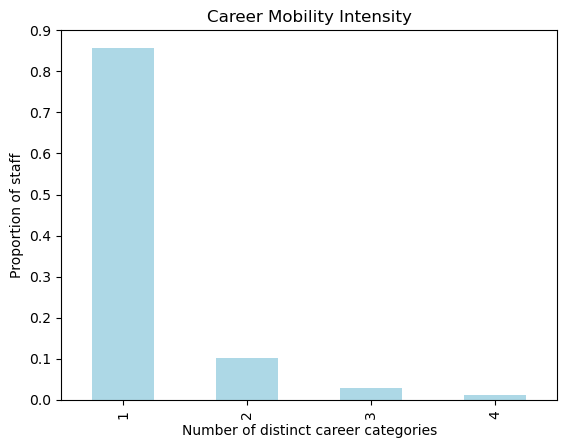

In [186]:
mobility = category_paths.copy()
mobility.index = mobility.index.map(len)

mobility = mobility.groupby(mobility.index).sum()
mobility = mobility / mobility.sum()

mobility.plot(kind='bar', color = "lightblue")

plt.xlabel('Number of distinct career categories')
plt.ylabel('Proportion of staff')
plt.title('Career Mobility Intensity')
plt.show()

In [171]:
pd.set_option('display.max_rows', None)
permanent_or_fixed = pd.crosstab(df["grade"], df["broad_contract_type"], normalize="index")
permanent_or_fixed = permanent_or_fixed.sort_values("Fixed", ascending= False)

permanent_or_fixed = permanent_or_fixed.reset_index()
permanent_or_fixed.columns.name = None
permanent_or_fixed

,grade,Fixed,Permanent
0,Grade 1,0.931034,0.068966
1,AC1,0.863636,0.136364
2,Grade 2,0.750000,0.250000
3,AC2,0.722807,0.277193
4,Grade 7,0.420382,0.579618
5,Grade 6,0.333333,0.666667
6,Grade 8,0.320000,0.680000
7,ECIT Grade 1,0.312500,0.687500
8,Grade 5,0.202381,0.797619
9,AC3,0.173333,0.826667


In [ ]:

x = permanent_or_fixed["Permanent"].values
grades = permanent_or_fixed["grade"].values


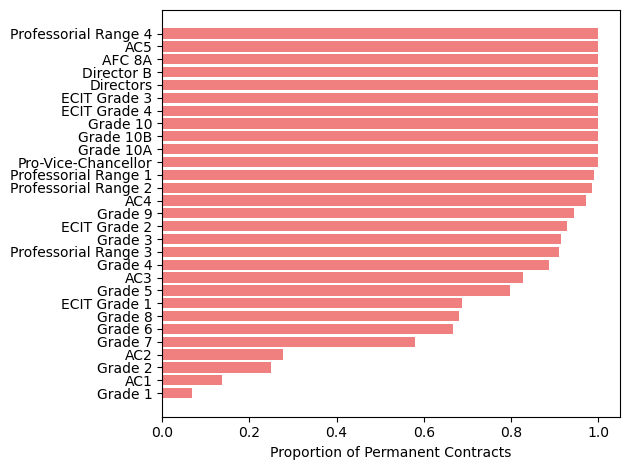

In [107]:
plt.barh(grades, x, color = "lightcoral")
plt.xlabel("Proportion of Permanent Contracts")
plt.tight_layout()

plt.show()




In [113]:
# Calculate time since joining university 
df["start_date"] = pd.to_datetime(df["start_date"], format = "%d/%m/%Y %H:%M")

In [114]:
df["years_since_start"] = (pd.Timestamp.today()- df["start_date"]).dt.days/365.25

In [116]:
df.head(10)

,Staff Key,faculty,school,broad_category,broad_contract_type,contract_type,contract_category,grade,gender,calc_fte,start_date,reporting_date,Staff ID,years_since_start
0,1140547C4,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Academic,Permanent,Perm on temp appt,Academic Non-Clinical,AC4,F,0.2,1998-07-01,31/05/2023 00:00,1140547,27.846680
1,1140547C4,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Academic,Permanent,Perm on temp appt,Academic Non-Clinical,AC4,F,0.8,1998-07-01,31/05/2023 00:00,1140547,27.846680
2,1140403 1,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Academic,Permanent,Perm on temp appt,Academic Non-Clinical,Professorial Range 1,M,0.4,2005-08-01,31/05/2023 00:00,1140403,20.761123
3,1140403 1,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Academic,Permanent,Perm on temp appt,Academic Non-Clinical,Professorial Range 1,M,0.6,2005-08-01,31/05/2023 00:00,1140403,20.761123
4,1140481 1,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Academic,Permanent,Perm on temp appt,Academic Non-Clinical,Professorial Range 1,M,0.2,2013-07-01,31/05/2023 00:00,1140481,12.845996
5,1140481 1,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Academic,Permanent,Perm on temp appt,Academic Non-Clinical,Professorial Range 1,M,0.8,2013-07-01,31/05/2023 00:00,1140481,12.845996
6,1100643 2,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Academic,Permanent,Perm on temp appt,Academic Non-Clinical,Professorial Range 2,F,0.3,2000-03-27,31/05/2023 00:00,1100643,26.108145
7,1100643 2,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Academic,Permanent,Perm on temp appt,Academic Non-Clinical,Professorial Range 2,F,0.7,2000-03-27,31/05/2023 00:00,1100643,26.108145
8,1100891 2,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Academic,Permanent,Perm on temp appt,Academic Non-Clinical,Professorial Range 2,M,0.3,2013-07-01,31/05/2023 00:00,1100891,12.845996
9,1100891 2,"Arts, Humanities and Social Sciences",Faculty Office AHSS,Academic,Permanent,Perm on temp appt,Academic Non-Clinical,Professorial Range 2,M,0.7,2013-07-01,31/05/2023 00:00,1100891,12.845996


In [ ]:
years_since_start = df["years_since_start"].to_numpy()

(array([0.07067776, 0.09347704, 0.07067776, 0.0410387 , 0.05862671,
        0.02866195, 0.02735913, 0.04234151, 0.01139964, 0.00977112,
        0.02117076, 0.02214787, 0.01074823, 0.01498238, 0.00944541,
        0.00977112, 0.0081426 , 0.00586267, 0.00195422, 0.00488556,
        0.00293134, 0.00390845, 0.00162852, 0.00065141, 0.00097711,
        0.00097711, 0.00065141, 0.00097711]),
 array([ 0.05201916,  1.78859881,  3.52517845,  5.26175809,  6.99833773,
         8.73491738, 10.47149702, 12.20807666, 13.9446563 , 15.68123594,
        17.41781559, 19.15439523, 20.89097487, 22.62755451, 24.36413415,
        26.1007138 , 27.83729344, 29.57387308, 31.31045272, 33.04703237,
        34.78361201, 36.52019165, 38.25677129, 39.99335093, 41.72993058,
        43.46651022, 45.20308986, 46.9396695 , 48.67624914]),
 <BarContainer object of 28 artists>)

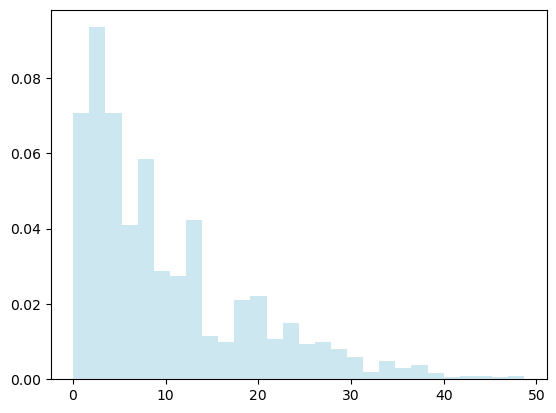

In [118]:
plt.hist(years_since_start, bins = 'auto',
         density = True,
         alpha = .6,
         label = 'Sample Std Deviation (ddof = 1)',
         color = 'lightblue'
         )

In [123]:
years_permanent = df.loc[df['broad_contract_type'] == "Permanent", 'years_since_start'].to_numpy()
years_fixed = df.loc[df['broad_contract_type'] == "Fixed", 'years_since_start'].to_numpy()

In [124]:
stats.mannwhitneyu(years_permanent, years_fixed)

MannwhitneyuResult(statistic=np.float64(516855.5), pvalue=np.float64(5.543424631271171e-105))

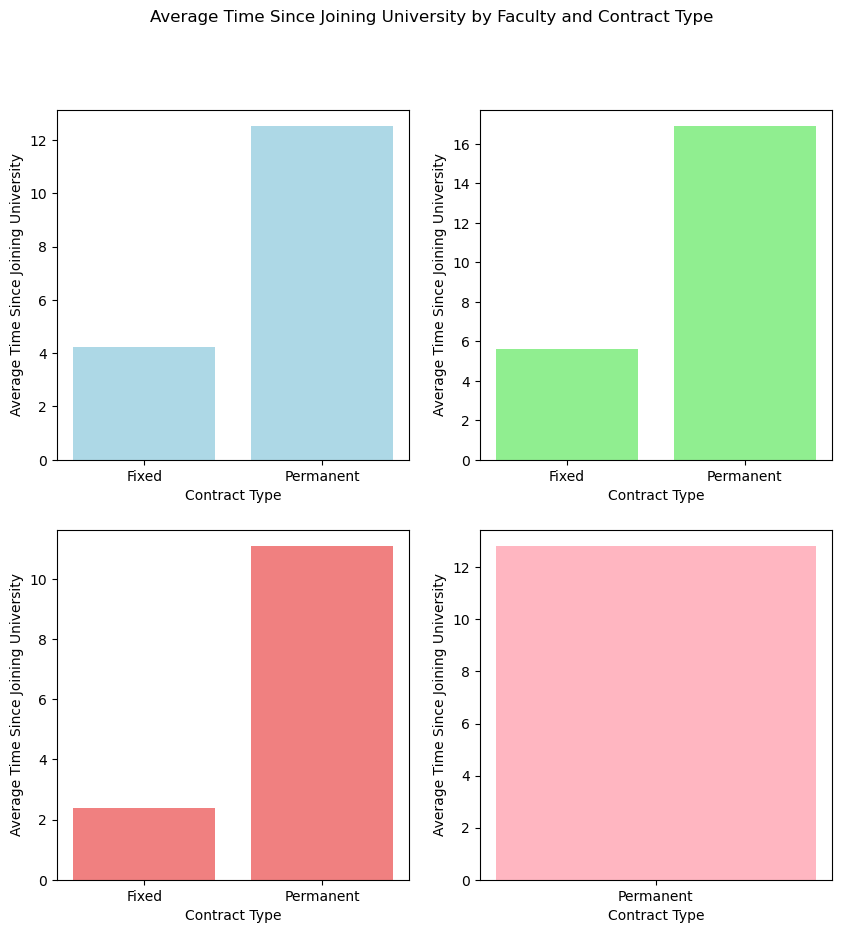

In [151]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2)

fig.set_figheight(10)
fig.set_figwidth(10)
fig.suptitle("Average Time Since Joining University by Faculty and Contract Type")

means1 = (
    df[df['faculty'] == 'Arts, Humanities and Social Sciences']
    .groupby('broad_contract_type')['years_since_start']
    .mean()
)


ax1.bar(means1.index, means1.values, color = "lightblue")

ax1.set_ylabel('Average Time Since Joining University')
ax1.set_xlabel('Contract Type')


means2 = (
    df[df['faculty'] == 'Engineering and Physical Sciences']
    .groupby('broad_contract_type')['years_since_start']
    .mean()
)


ax2.bar(means2.index, means2.values, color = "lightgreen")

ax2.set_ylabel('Average Time Since Joining University')
ax2.set_xlabel('Contract Type')


means3 = (
    df[df['faculty'] == 'Belfast Region City Deal']
    .groupby('broad_contract_type')['years_since_start']
    .mean()
)


ax3.bar(means3.index, means3.values, color = "lightcoral")

ax3.set_ylabel('Average Time Since Joining University')
ax3.set_xlabel('Contract Type')


means4 = (
    df[df['faculty'] == 'Corporate']
    .groupby('broad_contract_type')['years_since_start']
    .mean()
)


ax4.bar(means4.index, means4.values, color = "lightpink")

ax4.set_ylabel('Average Time Since Joining University')
ax4.set_xlabel('Contract Type')


plt.show()

